In [5]:
!pip install librosa scipy matplotlib numpy seaborn pmdarina --quiet

ERROR: Could not find a version that satisfies the requirement pmdarina (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for pmdarina


# Лабораторная 5

Анализируем данные датчика CO2 из обсерватории Мауна-Лоа (Гавайи). Период: март 1958 — декабрь 1980.

- Определим тренд и сезонность.
- Проверим стационарность.
- Разобьём на обучающую (90%) и тестовую (10%) выборки.
- Найдём кандидатов SARIMAX по ACF и PACF.
- Выполним поиск по сетке.
- Выберем лучшую модель по метрикам и нормальности остатков.
- Сравним с AutoARIMA.

Модель: SARIMA(p,d,q)(P,D,Q)[s]
Цель: построить оптимальную SARIMAX и сравнить с AutoARIMA.

## Подключение библиотек

In [19]:
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning
warnings.simplefilter("ignore", ConvergenceWarning)
warnings.simplefilter("ignore", ValueWarning)
warnings.simplefilter("ignore", UserWarning)

import time
from itertools import product
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
#from tqdm.notebook import tqdm
from tqdm import tqdm
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import month_plot, plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import mse
from statsmodels.tsa.statespace.tools import diff
import pmdarima as pm

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = [11, 7]
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

## Загрузка данных CO2

In [7]:
co2 = pd.read_csv(
    "https://zenodo.org/records/10951538/files/arima_co2.csv?download=1",
    header=0,
    names=["idx", "co2"],
    skipfooter=2,
    engine="python"
)
co2["idx"] = pd.to_datetime(co2["idx"])
co2.set_index("idx", inplace=True)
co2.index.name = None

print(f"Размер: {co2.shape}")
print(f"Период: {co2.index[0].strftime('%B %Y')} — {co2.index[-1].strftime('%B %Y')}")
co2.head()

Размер: (192, 1)
Период: January 1965 — December 1980


,co2
1965-01-01,319.32
1965-02-01,320.36
1965-03-01,320.82
1965-04-01,322.06
1965-05-01,322.17


## Шаг 1: Анализ тренда и сезонности

### Исходный ряд и декомпозиция

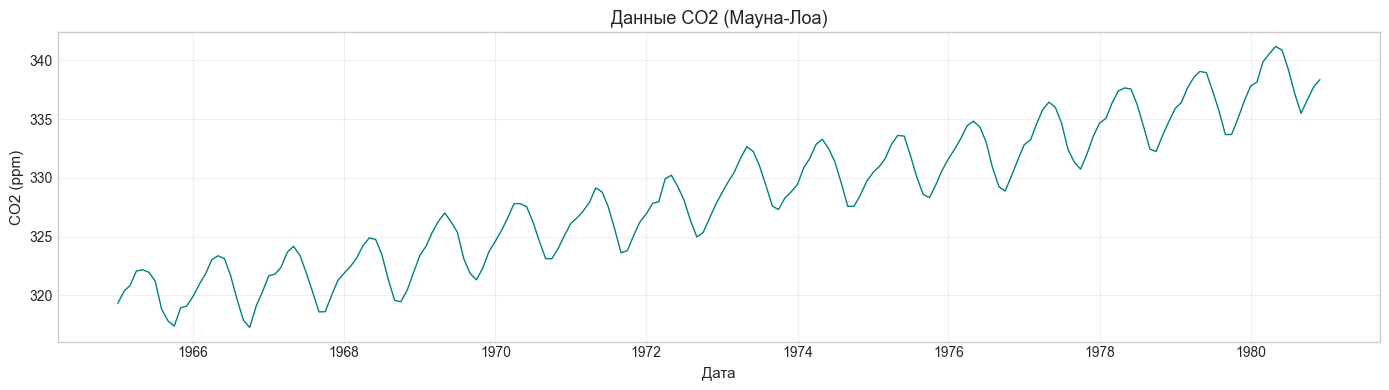

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(co2["co2"], color="teal", linewidth=1.0)
ax.set_title("Данные CO2 (Мауна-Лоа)", fontsize=13)
ax.set_xlabel("Дата", fontsize=11)
ax.set_ylabel("CO2 (ppm)", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Декомпозиция (seasonal_decompose)

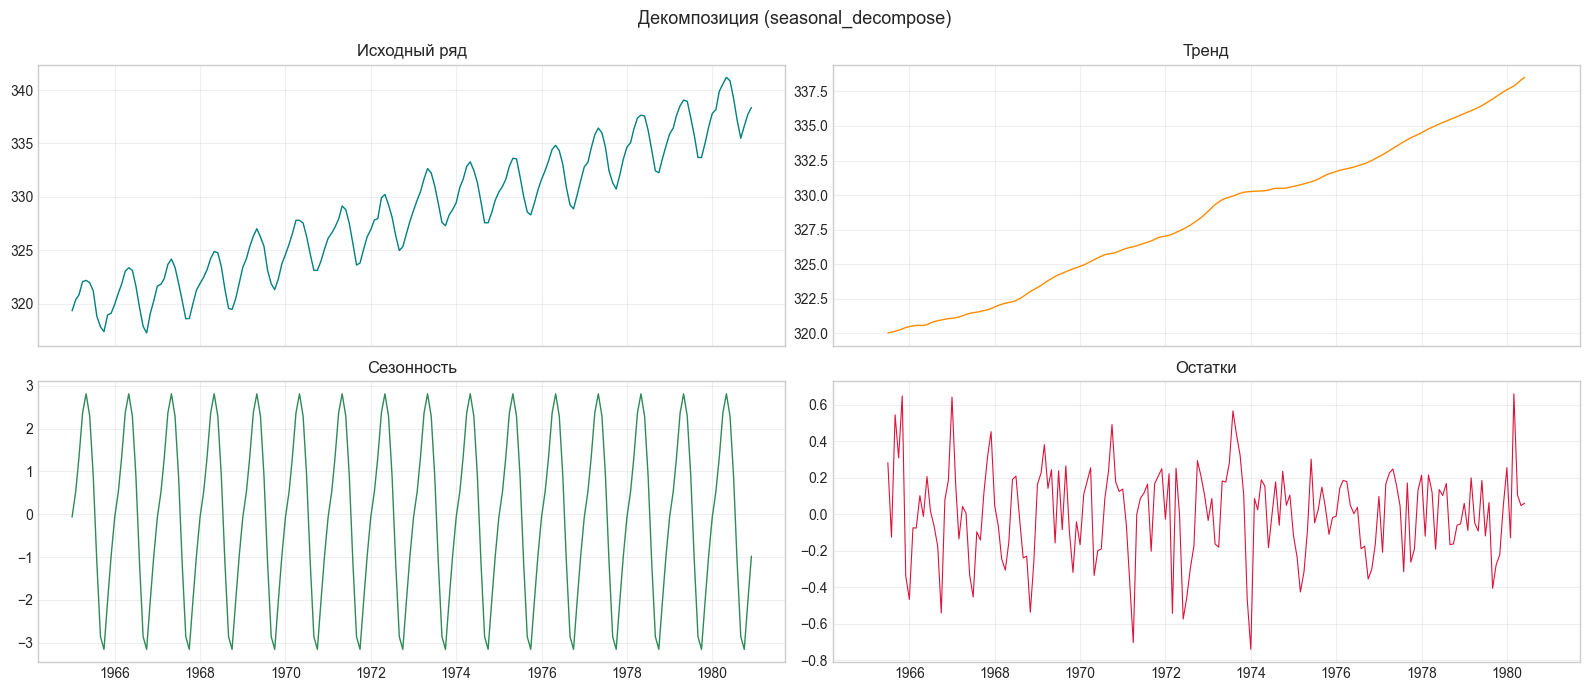

In [9]:
dec_sd = seasonal_decompose(co2["co2"], model="additive", period=12)

fig, axs = plt.subplots(2, 2, sharex=True, figsize=(16, 7))
fig.suptitle("Декомпозиция (seasonal_decompose)", fontsize=13)

axs[0, 0].plot(co2["co2"], color="teal", linewidth=1.0)
axs[0, 0].set_title("Исходный ряд")
axs[0, 1].plot(dec_sd.trend, color="darkorange", linewidth=1.0)
axs[0, 1].set_title("Тренд")
axs[1, 0].plot(dec_sd.seasonal, color="seagreen", linewidth=1.0)
axs[1, 0].set_title("Сезонность")
axs[1, 1].plot(dec_sd.resid, color="crimson", linewidth=0.8)
axs[1, 1].set_title("Остатки")

for ax in axs.flatten():
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Декомпозиция (STL)

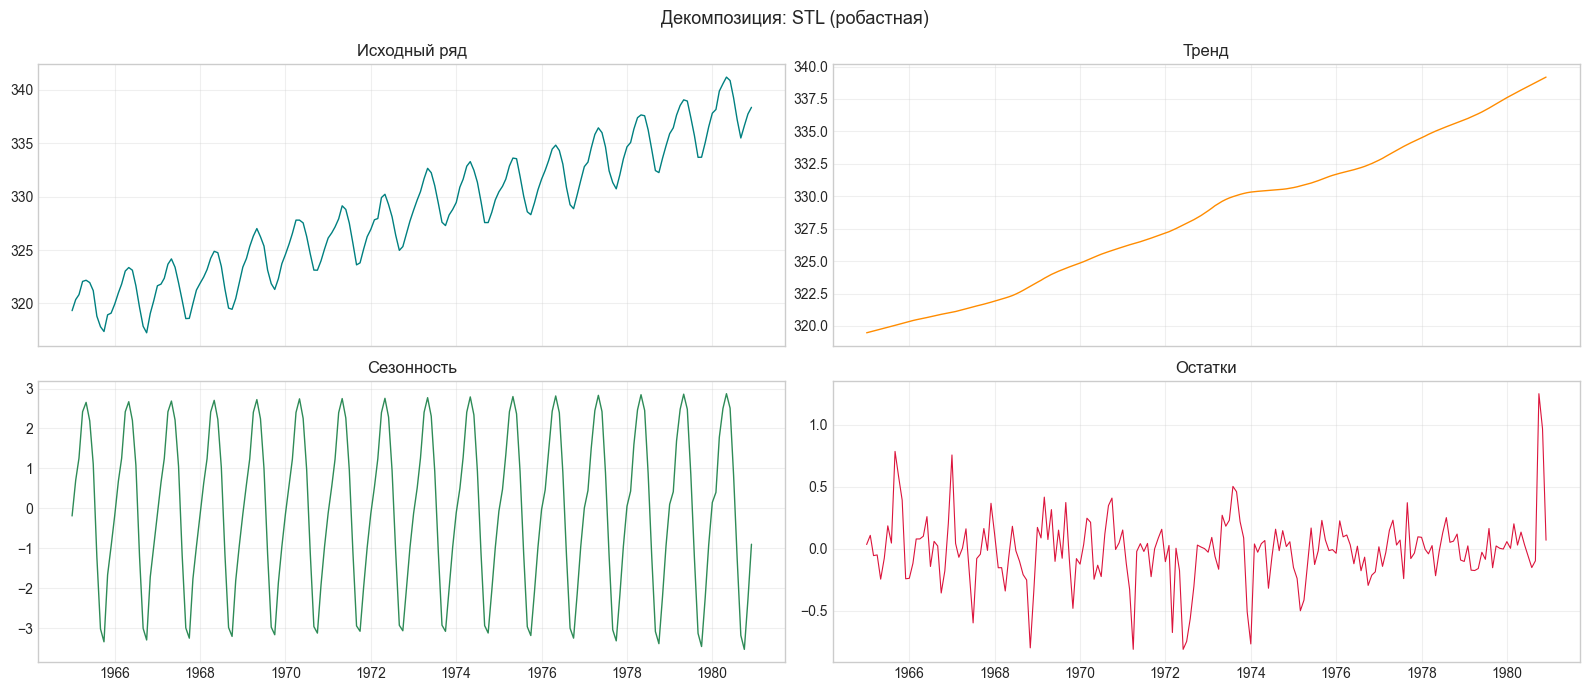

In [10]:
dec_stl = STL(co2["co2"], period=12, seasonal=13, robust=True).fit()

fig, axs = plt.subplots(2, 2, sharex=True, figsize=(16, 7))
fig.suptitle("Декомпозиция: STL (робастная)", fontsize=13)

axs[0, 0].plot(co2["co2"], color="teal", linewidth=1.0)
axs[0, 0].set_title("Исходный ряд")
axs[0, 1].plot(dec_stl.trend, color="darkorange", linewidth=1.0)
axs[0, 1].set_title("Тренд")
axs[1, 0].plot(dec_stl.seasonal, color="seagreen", linewidth=1.0)
axs[1, 0].set_title("Сезонность")
axs[1, 1].plot(dec_stl.resid, color="crimson", linewidth=0.8)
axs[1, 1].set_title("Остатки")

for ax in axs.flatten():
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Оба метода показывают восходящий нелинейный тренд. Темп роста ускоряется со временем.

Сезонная составляющая выражена чётко. Амплитуда колебаний примерно постоянна.

Остатки после исключения тренда и сезонности выглядят как белый шум.

## Шаг 2: Проверка стационарности

Тесты ADF

=== Исходный ряд ===
  Статистика: 1.2697
  p-значение: 0.9964
  Критические: 1%: -3.467, 5%: -2.878, 10%: -2.575
  Результат: Нестационарный (p >= 0.05)



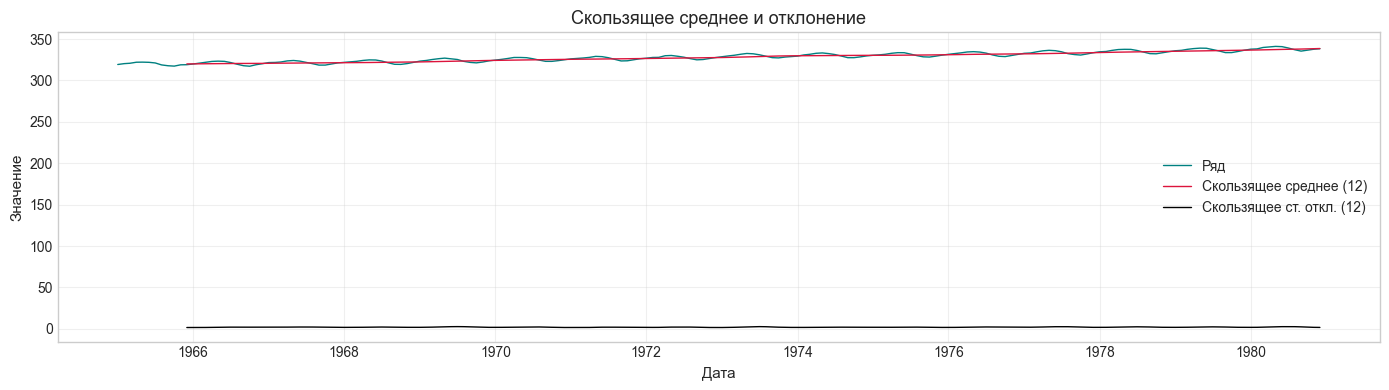

=== Сезонное дифференцирование (D=1) ===
  Статистика: -2.8202
  p-значение: 0.0554
  Критические: 1%: -3.471, 5%: -2.879, 10%: -2.576
  Результат: Нестационарный (p >= 0.05)



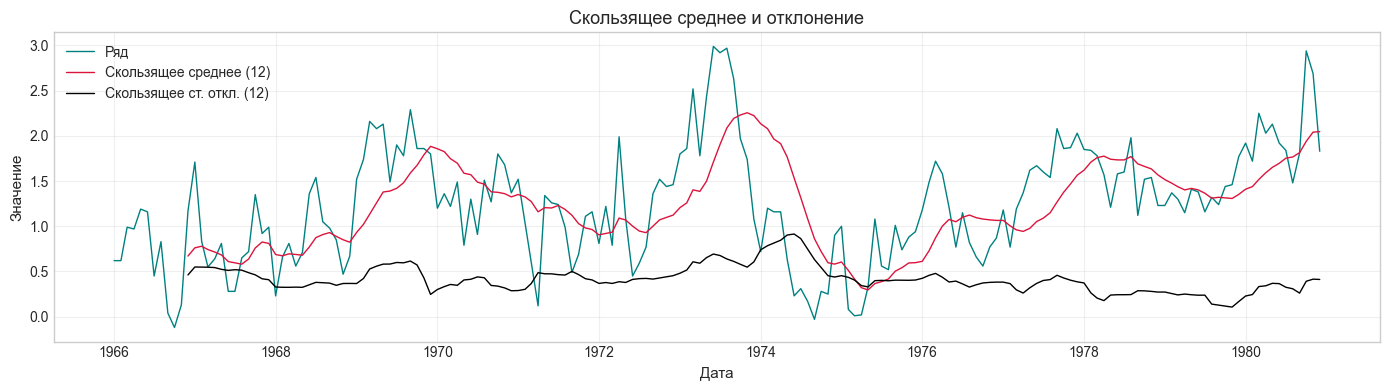

=== Сезонное + обычное дифференцирование (D=1, d=1) ===
  Статистика: -5.2093
  p-значение: 0.0000
  Критические: 1%: -3.470, 5%: -2.879, 10%: -2.576
  Результат: Стационарный (p < 0.05)



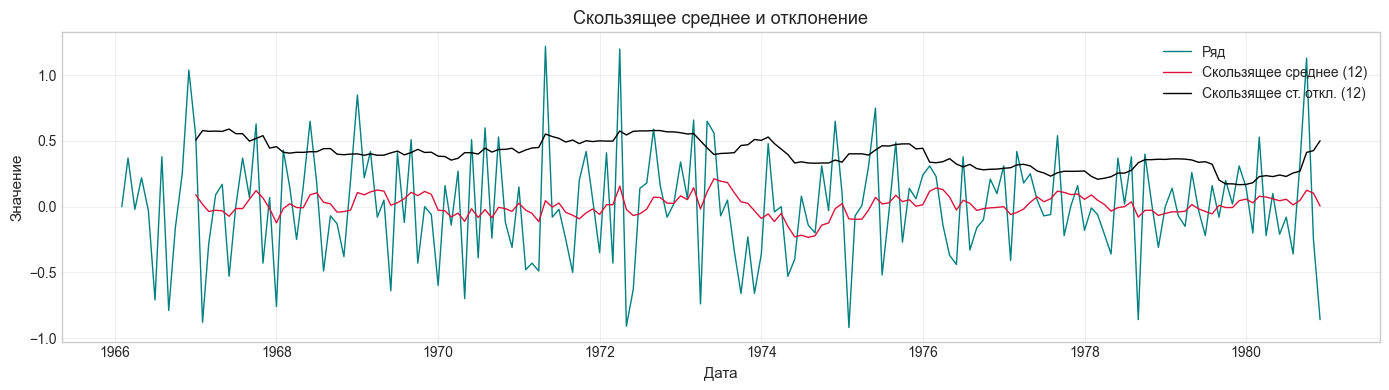

In [11]:
def check_adf(series, show_plots=True):
    res = adfuller(series, autolag="AIC")
    print(f"  Статистика: {res[0]:.4f}")
    print(f"  p-значение: {res[1]:.4f}")
    crit = ", ".join([f"{k}: {v:.3f}" for k, v in res[4].items()])
    print(f"  Критические: {crit}")
    verdict = "Стационарный (p < 0.05)" if res[1] < 0.05 else "Нестационарный (p >= 0.05)"
    print(f"  Результат: {verdict}\n")

    if show_plots:
        rm = series.rolling(window=12).mean()
        rs = series.rolling(window=12).std()
        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(series, color="teal", label="Ряд", linewidth=1.0)
        ax.plot(rm, color="crimson", label="Скользящее среднее (12)", linewidth=1.0)
        ax.plot(rs, color="black", label="Скользящее ст. откл. (12)", linewidth=1.0)
        ax.set_title("Скользящее среднее и отклонение", fontsize=13)
        ax.set_xlabel("Дата", fontsize=11)
        ax.set_ylabel("Значение", fontsize=11)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

print("=== Исходный ряд ===")
check_adf(co2["co2"])

print("=== Сезонное дифференцирование (D=1) ===")
check_adf(co2["co2"].diff(12).dropna())

print("=== Сезонное + обычное дифференцирование (D=1, d=1) ===")
check_adf(co2["co2"].diff(12).diff().dropna())

Исходный ряд нестационарен из-за восходящего тренда (p ~ 1).

Одного сезонного дифференцирования недостаточно (p = 0.055). Скользящее среднее нестабильно.

Двойное дифференцирование устраняет тренд и сезонность. Ряд стационарен (p < 0.0001).

## Шаг 3: Разделение на обучающую и тестовую выборки

Разделение данных 90%/10%

In [12]:
split_idx = int(len(co2) * 0.9)
train = co2.iloc[:split_idx]
test  = co2.iloc[split_idx:]

print(f"Обучающая: {len(train)} наблюдений  ({train.index[0].strftime('%Y-%m')} — {train.index[-1].strftime('%Y-%m')})")
print(f"Тестовая  : {len(test)}  наблюдений  ({test.index[0].strftime('%Y-%m')} — {test.index[-1].strftime('%Y-%m')})")
print(f"Сезонных циклов в тесте: {len(test) / 12:.1f}")

Обучающая: 172 наблюдений  (1965-01 — 1979-04)
Тестовая  : 20  наблюдений  (1979-05 — 1980-12)
Сезонных циклов в тесте: 1.7


График разделения

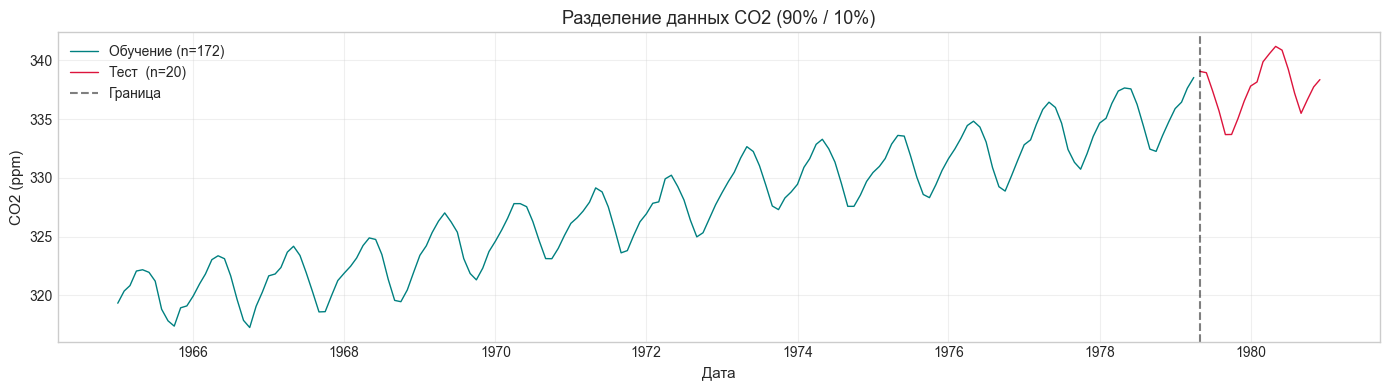

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train["co2"], label=f"Обучение (n={len(train)})", color="teal", linewidth=1.0)
ax.plot(test["co2"],  label=f"Тест  (n={len(test)})",  color="crimson", linewidth=1.0)
ax.axvline(x=test.index[0], color="black", linestyle="--", alpha=0.5, label="Граница")
ax.set_title("Разделение данных CO2 (90% / 10%)", fontsize=13)
ax.set_xlabel("Дата", fontsize=11)
ax.set_ylabel("CO2 (ppm)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Датасет охватывает ~192 наблюдения. Разделение 90/10 даёт ~172 в обучении и ~20 в тесте.

Разделение строго по временной границе обучение содержит только прошлое относительно теста.

## Шаг 4: Определение параметров-кандидатов через ACF и PACF

Дифференцирование и фильтрация по ADF

In [14]:
def make_diffs(timeseries, s, D_max=2, d_max=2):
    ts = timeseries.copy()
    seas_d = []
    for i in range(D_max + 1):
        ts.name = f"d0_D{i}_s{s}"
        seas_d.append(ts.copy())
        ts = ts.diff(periods=s)
    seas_df = pd.DataFrame(seas_d).T

    gen_d = []
    for j, s_ts in enumerate(seas_d):
        cur = s_ts.copy()
        for i in range(1, d_max + 1):
            cur = cur.diff()
            cur.name = f"d{i}_D{j}_s{s}"
            gen_d.append(cur.copy())
    gen_df = pd.DataFrame(gen_d).T

    return pd.concat([seas_df, gen_df], axis=1)

Выполняет тест ADF для всех столбцов и возвращает сводную таблицу

In [15]:
def adf_summary(df_diff):
    summary = []
    for col in df_diff.columns:
        series_clean = df_diff[col].dropna()
        a, b, c, d, e, f = adfuller(series_clean)
        g, h, k = list(e.values())
        summary.append([a, b, c, d, g, h, k])

    columns = ["Тест-статистика", "p-значение", "Лагов", "Наблюдений",
               "Критич.1%", "Критич.5%", "Критич.10%"]
    return pd.DataFrame(summary, index=df_diff.columns, columns=columns)

df_diff = make_diffs(train["co2"], s=12, D_max=2, d_max=2)
summary = adf_summary(df_diff)
summary_passed = summary[summary["p-значение"] < 0.05]
print(f"Прошли ADF (p < 0.05): {len(summary_passed)} из {len(summary)} комбинаций\n")
print("Стационарные кандидаты:")
display(summary_passed[["p-значение", "Тест-статистика"]].round(4))

index_list = list(summary_passed.index)
passed_series = df_diff[index_list].sort_index(axis=1)

Прошли ADF (p < 0.05): 8 из 9 комбинаций

Стационарные кандидаты:


,p-значение,Тест-статистика
d0_D1_s12,0.0406,-2.9430
d0_D2_s12,0.0099,-3.4318
d1_D0_s12,0.0037,-3.7307
d2_D0_s12,0.0000,-10.4251
d1_D1_s12,0.0000,-5.0470
d2_D1_s12,0.0000,-5.0814
d1_D2_s12,0.0000,-4.8313
d2_D2_s12,0.0001,-4.7923


Значимые выбросы PACF (AR-кандидаты) и ACF (MA-кандидаты)

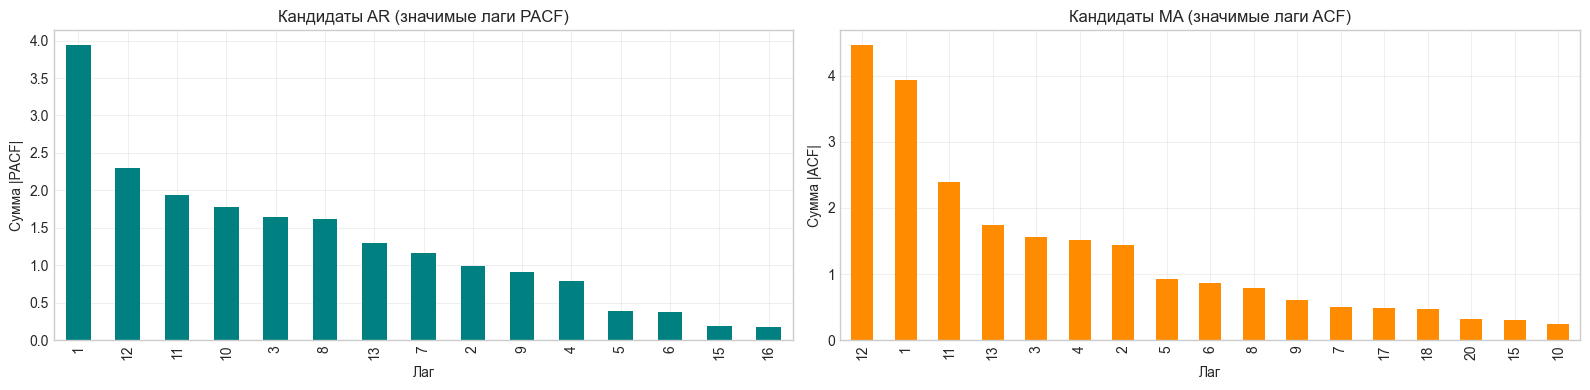

In [16]:
df_sp_p = pd.DataFrame()
for col in passed_series.columns:
    PACF_vals, PACF_ci = pacf(passed_series[col].dropna(), alpha=0.05, method="ywm")
    ci_ll = PACF_ci[:, 0] - PACF_vals
    ci_ul = PACF_ci[:, 1] - PACF_vals
    sp1 = np.where(PACF_vals < ci_ll)[0]
    sp2 = np.where(PACF_vals > ci_ul)[0]
    sp1_vals = pd.Series(np.abs(PACF_vals[PACF_vals < ci_ll]), index=sp1)
    sp2_vals = pd.Series(PACF_vals[PACF_vals > ci_ul], index=sp2)
    df_sp_p = pd.concat([df_sp_p, sp1_vals, sp2_vals], axis=1)

df_sp_p = df_sp_p.sort_index()
pacf_sums = df_sp_p.iloc[1:].T.sum().dropna().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
pacf_sums.plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Кандидаты AR (значимые лаги PACF)")
axes[0].set_xlabel("Лаг")
axes[0].set_ylabel("Сумма |PACF|")
axes[0].grid(True, alpha=0.3)

df_sp_q = pd.DataFrame()
for col in passed_series.columns:
    ACF_vals, ACF_ci = acf(passed_series[col].dropna(), alpha=0.05)
    ci_ll = ACF_ci[:, 0] - ACF_vals
    ci_ul = ACF_ci[:, 1] - ACF_vals
    sp1 = np.where(ACF_vals < ci_ll)[0]
    sp2 = np.where(ACF_vals > ci_ul)[0]
    sp1_vals = pd.Series(np.abs(ACF_vals[ACF_vals < ci_ll]), index=sp1)
    sp2_vals = pd.Series(ACF_vals[ACF_vals > ci_ul], index=sp2)
    df_sp_q = pd.concat([df_sp_q, sp1_vals, sp2_vals], axis=1)

df_sp_q = df_sp_q.sort_index()
acf_sums = df_sp_q.iloc[1:].T.sum().dropna().sort_values(ascending=False)
acf_sums.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Кандидаты MA (значимые лаги ACF)")
axes[1].set_xlabel("Лаг")
axes[1].set_ylabel("Сумма |ACF|")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Тест ADF прошли только комбинации с сезонным дифференцированием D=1.

PACF: значимые лаги 1 и 2, значит p = 0, 1 или 2. ACF: выбросы на первых двух лагах, q = 0, 1 или 2.
На 12-м лаге есть пики, поэтому P = 0 или 1, Q = 0 или 1. D=1, s=12.

Перебираем 72 комбинации: p(3) * d(2) * q(3) * P(2) * D(1) * Q(2)

## Шаг 5: Поиск по сетке

Перебираем комбинации SARIMA и возвращаем DataFrame метрик качества

In [20]:
warnings.simplefilter("ignore")

def SARIMA_grid(endog, order, seasonal_order):
    model_info = []
    for i in tqdm(order, desc="pdq"):
        for j in seasonal_order:
            try:
                model_fit = SARIMAX(endog=endog, order=i, seasonal_order=j).fit(disp=False)
                predict = model_fit.predict()
                endog_vals = endog.values if hasattr(endog, "values") else endog
                pred_vals  = predict.values if hasattr(predict, "values") else predict
                MAPE = float(np.abs((endog_vals[1:] - pred_vals[1:]) / endog_vals[1:]).mean())
                MSE_val = float(mse(endog_vals[1:], pred_vals[1:]))
                AIC = model_fit.aic
                BIC = model_fit.bic
                model_info.append([i, j, MAPE, MSE_val, AIC, BIC])
            except Exception:
                continue

    columns = ["порядок", "сезонный_порядок", "MAPE", "MSE", "AIC", "BIC"]
    return pd.DataFrame(data=model_info, columns=columns)


p_vals = [0, 1, 2]
d_vals = [0, 1]
q_vals = [0, 1, 2]
P_vals = [0, 1]
D_vals = [1]
Q_vals = [0, 1]
s_val  = [12]

pdq   = list(product(p_vals, d_vals, q_vals))
PDQs  = list(product(P_vals, D_vals, Q_vals, s_val))

print(f"Всего комбинаций: {len(pdq)} * {len(PDQs)} = {len(pdq) * len(PDQs)}")

start_time = time.time()
model_info = SARIMA_grid(endog=train["co2"], order=pdq, seasonal_order=PDQs)
elapsed = time.time() - start_time

print(f"\nУспешно подобрано: {len(model_info)} из {len(pdq) * len(PDQs)}")
print(f"Время выполнения: {elapsed:.1f} сек ({elapsed/60:.1f} мин)")

print("\n10 лучших моделей по AIC:")
display(model_info.nsmallest(10, "AIC").reset_index(drop=True))

Всего комбинаций: 18 * 4 = 72





















pdq: 100%|██████████| 18/18 [00:50<00:00,  2.82s/it]


Успешно подобрано: 72 из 72
Время выполнения: 50.7 сек (0.8 мин)

10 лучших моделей по AIC:


,порядок,сезонный_порядок,MAPE,MSE,AIC,BIC
0,"(0, 1, 1)","(0, 1, 1, 12)",0.003812,147.662389,90.469500,99.676212
1,"(1, 1, 1)","(0, 1, 1, 12)",0.003808,147.660730,91.092128,103.367745
2,"(1, 1, 0)","(0, 1, 1, 12)",0.003810,147.663008,91.388791,100.595504
3,"(2, 1, 1)","(0, 1, 1, 12)",0.003806,147.660250,91.827067,107.171588
4,"(0, 1, 2)","(0, 1, 1, 12)",0.003812,147.661995,92.156839,104.432456
5,"(1, 1, 2)","(0, 1, 1, 12)",0.003807,147.660440,92.315154,107.659675
6,"(0, 1, 1)","(1, 1, 1, 12)",0.003811,147.662521,92.320091,104.595708
7,"(2, 1, 2)","(0, 1, 1, 12)",0.003804,147.659563,93.050112,111.463538
8,"(1, 1, 1)","(1, 1, 1, 12)",0.003808,147.660781,93.083712,108.428233
9,"(1, 1, 0)","(1, 1, 1, 12)",0.003809,147.663156,93.196576,105.472192


Все 72 модели сошлись без ошибок. Перебор занял около 50 секунд.

Лучшая по AIC: SARIMA(0,1,1)(0,1,1,12), AIC=90.47. Разрыв со вторым местом небольшой.
Все топовые модели сходятся на Q=1 в сезонной части.

## Шаг 6: Выбор модели и анализ остатков

Лучшие модели по каждому критерию и прогнозы

,порядок,сезонный_порядок,MAPE,MSE,AIC,BIC
0,"(2, 1, 2)","(0, 1, 1, 12)",0.003804,147.659563,93.050112,111.463538
1,"(0, 1, 1)","(0, 1, 1, 12)",0.003812,147.662389,90.469500,99.676212


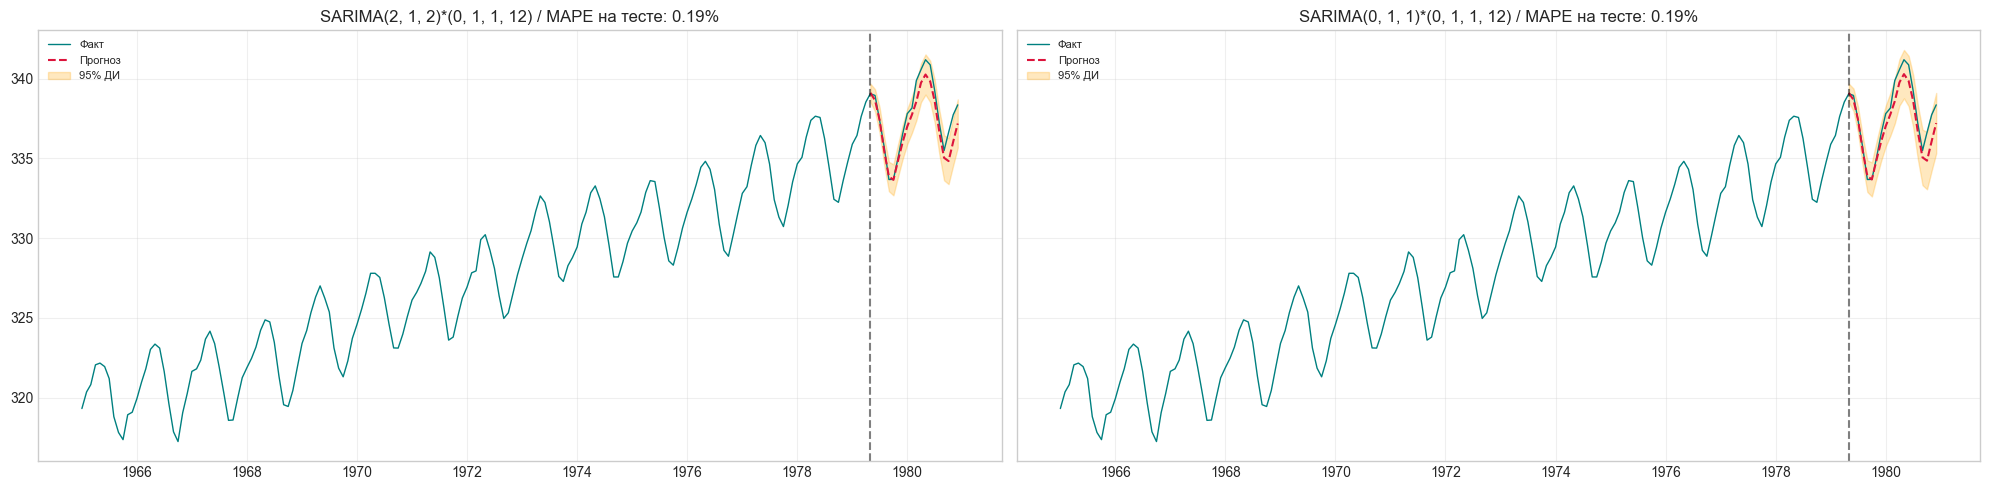

In [21]:
L1 = model_info[model_info["MAPE"] == model_info["MAPE"].min()].head(1)
L2 = model_info[model_info["MSE"]  == model_info["MSE"].min()].head(1)
L3 = model_info[model_info["AIC"]  == model_info["AIC"].min()].head(1)
L4 = model_info[model_info["BIC"]  == model_info["BIC"].min()].head(1)

best_models = pd.concat([L1, L2, L3, L4]).drop_duplicates(subset=["порядок", "сезонный_порядок"])
best_models = best_models.reset_index(drop=True)

display(best_models)

n_models = len(best_models)
preds, ci_low, ci_up, mape_test_list = [], [], [], []

for i in range(n_models):
    ord_i  = tuple(best_models.iloc[i]["порядок"])
    sord_i = tuple(best_models.iloc[i]["сезонный_порядок"])
    fit = SARIMAX(endog=train["co2"], order=ord_i, seasonal_order=sord_i).fit(disp=False)
    pred_summary = fit.get_prediction(test.index[0], test.index[-1]).summary_frame()
    preds.append(pred_summary["mean"])
    ci_low.append(pred_summary["mean_ci_lower"])
    ci_up.append(pred_summary["mean_ci_upper"])
    mape_val = float(np.abs((test["co2"].values - pred_summary["mean"].values) / test["co2"].values).mean())
    mape_test_list.append(mape_val)

nrows = (n_models + 1) // 2
fig, axs = plt.subplots(nrows, 2, figsize=(20, 5 * nrows), sharex=True, sharey=True)
axs = np.array(axs).flatten()

for k in range(n_models):
    ax = axs[k]
    ord_k  = tuple(best_models.iloc[k]["порядок"])
    sord_k = tuple(best_models.iloc[k]["сезонный_порядок"])
    ax.plot(co2["co2"], label="Факт", color="teal", linewidth=1)
    ax.plot(preds[k],   label="Прогноз", color="crimson", linestyle="--", linewidth=1.5)
    ax.fill_between(test.index, ci_low[k], ci_up[k], color="orange", alpha=0.25, label="95% ДИ")
    ax.axvline(test.index[0], color="black", linestyle="--", alpha=0.5)
    ax.set_title(f"SARIMA{ord_k}*{sord_k} / MAPE на тесте: {mape_test_list[k]:.2%}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for k in range(n_models, len(axs)):
    axs[k].set_visible(False)

plt.tight_layout()
plt.show()

Диагностика остатков лучшей модели по AIC

Лучшая модель по AIC: SARIMA(0, 1, 1)*(0, 1, 1, 12)
AIC = 90.47  /  BIC = 99.68
MAPE (train) = 0.0038



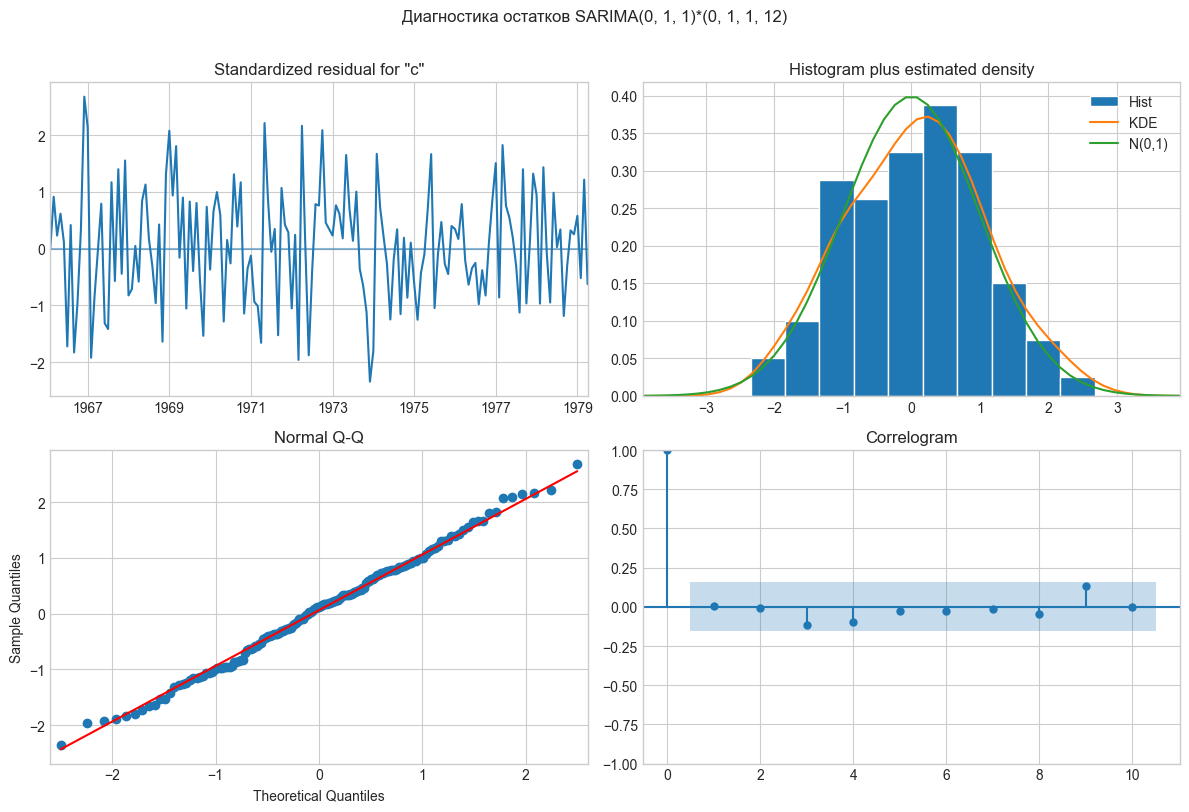


Сводная таблица диагностики остатков:


,Тест,p-значение,Ho не отвергается
0,Жак-Бера (нормальность),0.6081,ok
1,Шапиро-Уилк (нормальность),0.0000,bad
2,Льюнг-Бокс (автокорр.),0.6954,ok
3,Гетероскедастичность,0.0278,bad


In [22]:
best_aic_row  = model_info.loc[model_info["AIC"].idxmin()]
best_ord      = tuple(best_aic_row["порядок"])
best_sord     = tuple(best_aic_row["сезонный_порядок"])

print(f"Лучшая модель по AIC: SARIMA{best_ord}*{best_sord}")
print(f"AIC = {best_aic_row['AIC']:.2f}  /  BIC = {best_aic_row['BIC']:.2f}")
print(f"MAPE (train) = {best_aic_row['MAPE']:.4f}\n")

best_fit = SARIMAX(endog=train["co2"], order=best_ord, seasonal_order=best_sord).fit(disp=False)

best_fit.plot_diagnostics(figsize=(12, 8))
plt.suptitle(f"Диагностика остатков SARIMA{best_ord}*{best_sord}", y=1.01)
plt.tight_layout()
plt.show()

residuals = best_fit.resid

jb_val, jb_p, _, _ = best_fit.test_normality("jarquebera")[0]
sw_stat, sw_p = stats.shapiro(residuals)
_, lb_pvals = best_fit.test_serial_correlation(method="ljungbox", lags=10)[0]
lb_p_mean = lb_pvals.mean()
_, het_p = best_fit.test_heteroskedasticity("breakvar", alternative="two-sided")[0]

diag_data = [
    ["Жак-Бера (нормальность)",   f"{jb_p:.4f}",    "ok" if jb_p  > 0.05 else "bad"],
    ["Шапиро-Уилк (нормальность)", f"{sw_p:.4f}",   "ok" if sw_p  > 0.05 else "bad"],
    ["Льюнг-Бокс (автокорр.)",     f"{lb_p_mean:.4f}", "ok" if lb_p_mean > 0.05 else "bad"],
    ["Гетероскедастичность",        f"{het_p:.4f}",   "ok" if het_p > 0.05 else "bad"],
]
diag_df = pd.DataFrame(diag_data, columns=["Тест", "p-значение", "Ho не отвергается"])
print("\nСводная таблица диагностики остатков:")
display(diag_df)

Лучшая модель: SARIMA(0,1,1)(0,1,1,12).

Жак-Бера прошёл (p=0.61), Льюнг-Бокс тоже (p=0.69). Шапиро-Уилк провалился (p~0).
Гетероскедастичность формально не прошла (p=0.03), но на глаз остатки выглядят однородно.

## Шаг 7: Сравнение с AutoARIMA

Запуск AutoARIMA (stepwise=True, trace=True):

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=170.140, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=116.893, Time=0.13 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.74 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=167.257, Time=0.03 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=112.261, Time=0.40 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.62 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.95 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=116.848, Time=0.19 sec


Exception ignored while calling deallocator <function tqdm.__del__ at 0x000001F3500580F0>:
Traceback (most recent call last):
  File "c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


 ARIMA(2,1,0)(2,1,0)[12]             : AIC=114.093, Time=0.60 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=111.836, Time=0.47 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=116.214, Time=0.27 sec
 ARIMA(1,1,1)(2,1,1)[12]             : AIC=inf, Time=1.71 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=inf, Time=0.86 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=111.627, Time=0.29 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=116.499, Time=0.13 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=1.82 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=inf, Time=0.77 sec
 ARIMA(0,1,2)(2,1,0)[12]             : AIC=113.136, Time=0.32 sec
 ARIMA(1,1,2)(2,1,0)[12]             : AIC=113.542, Time=0.85 sec
 ARIMA(0,1,1)(2,1,0)[12] intercept   : AIC=113.547, Time=0.59 sec

Best model:  ARIMA(0,1,1)(2,1,0)[12]          
Total fit time: 12.801 seconds

                                      SARIMAX Results                                      
Dep. Variable:                                   y  

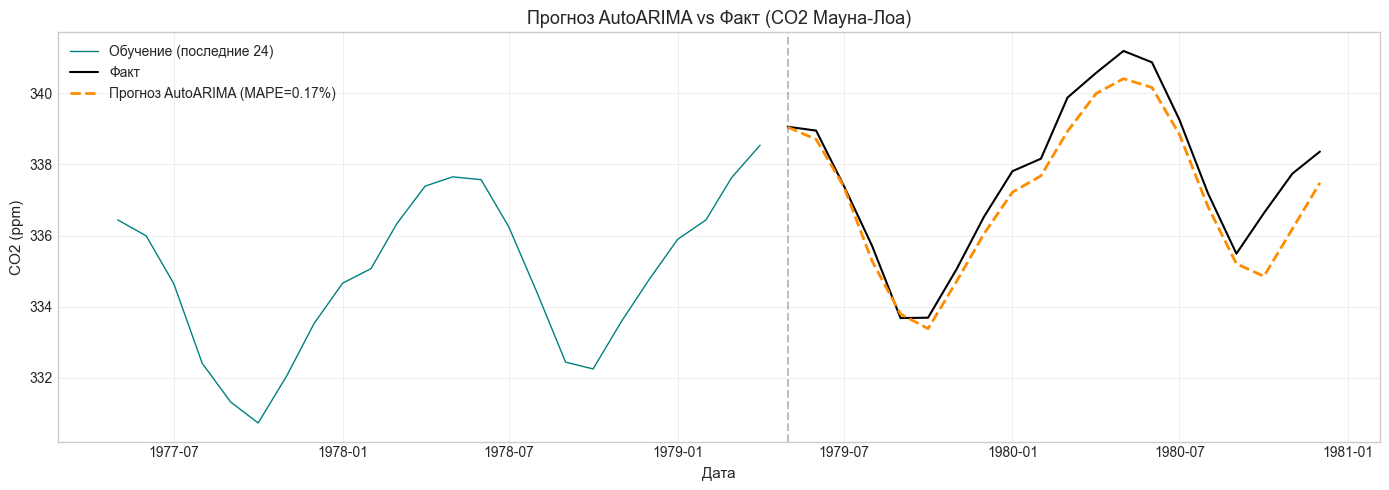


Сравнительная таблица:


,Модель,Порядок,Сезонный порядок,AIC,MAPE на тесте
0,Grid Search (лучший по AIC),"(0, 1, 1)","(0, 1, 1, 12)",90.5,0.19%
1,AutoARIMA,"(0, 1, 1)","(2, 1, 0, 12)",—,0.17%


In [23]:
print("Запуск AutoARIMA (stepwise=True, trace=True):\n")
auto_model = pm.auto_arima(
    train["co2"],
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    m=12,
    seasonal=True,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None,
    D=1,
    test="adf",
    trace=True,
    stepwise=True,
    error_action="ignore",
    suppress_warnings=True
)

print("\n" + "=" * 60)
print(auto_model.summary())

auto_forecast = auto_model.predict(n_periods=len(test))
auto_forecast = pd.Series(auto_forecast, index=test.index)
auto_mape = float(np.abs((test["co2"].values - auto_forecast.values) / test["co2"].values).mean())

print(f"\nMAPE AutoARIMA на тесте: {auto_mape:.4f} ({auto_mape:.2%})")

auto_ord  = auto_model.order
auto_sord = auto_model.seasonal_order

last_n = 24
train_tail = train["co2"].iloc[-last_n:]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_tail, label=f"Обучение (последние {last_n})", color="teal", linewidth=1.0)
ax.plot(test["co2"], label="Факт", color="black", linewidth=1.5)
ax.plot(auto_forecast, label=f"Прогноз AutoARIMA (MAPE={auto_mape:.2%})",
        color="darkorange", linestyle="--", linewidth=2)
ax.axvline(test.index[0], color="gray", linestyle="--", alpha=0.5)
ax.set_title("Прогноз AutoARIMA vs Факт (CO2 Мауна-Лоа)", fontsize=13)
ax.set_xlabel("Дата", fontsize=11)
ax.set_ylabel("CO2 (ppm)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_aic_row2 = model_info.loc[model_info["AIC"].idxmin()]
compare_data = [
    ["Grid Search (лучший по AIC)", str(tuple(best_aic_row2["порядок"])),
     str(tuple(best_aic_row2["сезонный_порядок"])),
     f"{best_aic_row2['AIC']:.1f}",
     f"{mape_test_list[0]:.2%}" if mape_test_list else "N/A"],
    ["AutoARIMA", str(auto_ord), str(auto_sord), "—", f"{auto_mape:.2%}"],
]
compare_df = pd.DataFrame(compare_data, columns=["Модель", "Порядок", "Сезонный порядок", "AIC", "MAPE на тесте"])
print("\nСравнительная таблица:")
display(compare_df)

AutoARIMA выбрал SARIMA(0,1,1)(2,1,0,12). Несезонная часть совпала, сезонная отличается вместо Q=1 взял P=2.

Результат AutoARIMA чуть лучше: MAPE 0.17% против 0.19% у grid search. Разница минимальная.

Обе модели показывают MAPE < 0.2% тоже отличный результат. Grid search дал более интерпретируемую модель с меньшим числом параметров.